**Jack Dai**

Spring 2026

CS 252: Mathematical Data Analysis and Visualization

# Project 5: Singular Value Decomposition and Recommender Systems

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 14})

np.set_printoptions(suppress=True, precision=5, legacy='1.25')

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 1: Preprocessing the MovieLens dataset

We will use SVD to recommend movies to users based on their and other people's ratings. Like your favorite streaming service (Netflix, Prime, Hulu, etc.) you will suggest movies that a user has not seen but is most likely to enjoy watching!

We will work with the [MovieLens dataset](https://grouplens.org/datasets/movielens/), which is composed of ~62,500 "star" ratings of movies. *Download and use the CSV files on the project website, which have been preprocessed to make your life easier.*

#### MovieLens variables
- `userId`: int label for a user. For example, a `userId` of `80` means "user 80". The ints are numbered `0, ..., num_users-1`. Each user has a unique label and the labels are consistent across fit and test sets (i.e. if a `userId` of `80` appears in both the fit and test sets, it is the same user in both cases).
- `movieId`: int label for a movie. For example, a `movieId` of `7` means "movie 7". The ints are numbered `0, ..., num_movies-1`. Each movie has a unique label and the labels are consistent across fit and test sets (i.e. if a `movieId` of `7` appears in both the fit and test sets, it is the same movie in both cases).
- `rating`: float representing a star rating on a scale of `0.5` stars (worst rating) to `5.0`  stars (best rating) in 0.5 star increments (i.e. possible ratings: `[0.5, 1.0, ..., 5.0]`).
- `timestamp`: int corresponding to when the movie was reviewed by the user. Larger values indicate later times.
- `title`: The string title of the movie rated (e.g. `Titanic (1997)`).
- `genres`: String containing the movie genres. Multiple genres for a movie are delimited by a `|` character (e.g. `Drama|Romance` means the movie has two genres — Drama and Romance).

### 1a. Load in the MovieLens dataset

In the cell below, load in the MovieLens dataset as a Pandas DataFrame (`movielens.csv`). Show the 1st five rows of the MovieLens DataFrame.

In [2]:
# YOUR CODE HERE
m_d = pd.read_csv('data/movielens.csv')
print(m_d.head())

   userId  movieId  rating  timestamp                        title  \
0       0        0     4.0  964982703             Toy Story (1995)   
1       0        2     4.0  964981247      Grumpier Old Men (1995)   
2       0        4     4.0  964982224                  Heat (1995)   
3       0       23     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       0       25     5.0  964982931   Usual Suspects; The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


### 1b. Determine the number of users and movies in the dataset

Currently, the data are organized as one long table where each sample (row) is only ONE specific rating. If a user rates multiple movies, they appear on separate lines. To run SVD, we will want to create a matrix where
- rows: users (user 0, user 1, user 2, ...).
- columns: movies (movie 0, movie 1, ...).

Before you can create this matrix, determine `N` (number of *unique* users) and `M` (number of *unique* movies) in the cell below.

Your should not hard code the number of users and movies (i.e. your code should work if the specific dataset were swapped out).

In [3]:
# YOUR CODE HERE
N = m_d['userId'].nunique()
M = m_d['movieId'].nunique()
print(N, M)

610 1050


### 1c. Build the user-item matrix

This is the "A data matrix" that will serve as the input to SVD.

1. Write the `user_item_matrix` function in `rec_util.py` that takes a pandas DataFrame and builds the **user-item matrix** that has shape `(N, M)`.
2. Call your `user_item_matrix` function to make the user-item matrix.

**Note:** "Item" here means "movie". 

In [4]:
from rec_util import user_item_matrix

In [5]:
# YOUR CODE HERE
A = user_item_matrix(m_d, N, M)
print(f'The shape of your user-item matrix is {A.shape=} and it should be (610, 1050).')
print(f'The user-item matrix is a ndarray as it should be? {isinstance(A, np.ndarray)}.')
print(f'The sum of ALL ratings is {A.sum()} and it should be 227818.5.')

The shape of your user-item matrix is A.shape=(610, 1050) and it should be (610, 1050).
The user-item matrix is a ndarray as it should be? True.
The sum of ALL ratings is 227818.5 and it should be 227818.5.


### 1d. Create fit and validation sets

This subtask involves setting aside an array of nonzero user ratings for validation so that you will be able to later assess the accuracy of the predicted ratings on rating not used to fit your recommender system. In the cell below:

1. Load in `movielens_val_indices.csv` as a DataFrame and print out a preview. Each row is the `(row, col)` index of a rating in `A` that should be entered into the validation set. (*total number of rows = number of validation samples*).
2. Extract ratings from `A` at these rows and cols and assign them to a 1D ndarray called `val_ratings`.
3. Make the fit set (`A_fit`): A **copy** of `A` except that you should set the ratings at the validation set `(rows, cols)` to "unrated" (set to 0).

In [6]:
# YOUR CODE HERE
val_idx = pd.read_csv('data/movielens_val_indices.csv')
print(val_idx.head())
print(val_idx.columns)

rows = val_idx['row_inds'].to_numpy()
cols = val_idx['col_inds'].to_numpy()

val_ratings = A[rows, cols]

A_fit = A.copy()
A_fit[rows, cols] = 0

   row_inds  col_inds
0       541       743
1       306       387
2       153       958
3       554       649
4       253       719
Index(['row_inds', 'col_inds'], dtype='str')


In [7]:
print(f'Your validation set ratings has shape {val_ratings.shape} and it should be (6252,).')
print(f'The first three validation set ratings are {val_ratings[:3]} and they should be [4. 2. 5.].')
print(f'The last three validation set ratings are {val_ratings[-3:]} and they should be [3. 3. 4.].')
print(f'The sum of all ratings in the original A matrix is {A.sum()} and it should be 227818.5.')
print(f'The sum of all ratings in the fit set A matrix is {A_fit.sum()} and it should be 205049.0.')

Your validation set ratings has shape (6252,) and it should be (6252,).
The first three validation set ratings are [4. 2. 5.] and they should be [4. 2. 5.].
The last three validation set ratings are [3. 3. 4.] and they should be [3. 3. 4.].
The sum of all ratings in the original A matrix is 227818.5 and it should be 227818.5.
The sum of all ratings in the fit set A matrix is 205049.0 and it should be 205049.0.


## Task 2: Recommender Model 1 (SVD)

Your goal is to implement and compare the accuracy of 3 different recommender systems:
1. Truncated SVD
2. Mean user rating
3. Funk SVD

The functionality that these recommender systems have in common should be implemented in the parent `Recommender` class (*such methods are noted below*).


### 2a. Implement `Recommender` and `SVD` recommender system classes

Let's start by implementing and testing the Truncated SVD recommender system (`SVD` class). This model involves computing the Truncated SVD of the fit set user-item matrix with `k` basis vectors. It uses prevalent factors/patterns to "fill in" ratings for unrated movies. The `SVD` class inherits from `Recommender` in `rec_sys.py`. I suggest working in the following order, but feel free to work in any order that you like!

1. constructor (Recommender)
2. `replace_missing_with_mean` (Recommender)
3. `fit` (SVD)
4. `predict` (SVD)
5. `predict_user_item_ratings` (Recommender)
6. `rmse` (Recommender)

In [8]:
from rec_sys import Recommender, SVD

#### (i) Test `replace_missing_with_mean`

In [9]:
test_rec = Recommender(1)
test_A = np.array([[1, 3, 0, 7, 9], [0, 0, 1, 0, 9], [2, 2, 2, 0, 2], [2, 0, 3, 3, 2]], dtype=float)
test_rep_A = test_rec.replace_missing_with_mean(test_A)
print('Your user-item matrix with filled in values for missing ratings are')
print(test_rep_A)
print('and should be:')
print('''[[1.  3.  5.  7.  9. ]
 [5.  5.  1.  5.  9. ]
 [2.  2.  2.  2.  2. ]
 [2.  2.5 3.  3.  2. ]]''')

Your user-item matrix with filled in values for missing ratings are
[[1.  3.  5.  7.  9. ]
 [5.  5.  1.  5.  9. ]
 [2.  2.  2.  2.  2. ]
 [2.  2.5 3.  3.  2. ]]
and should be:
[[1.  3.  5.  7.  9. ]
 [5.  5.  1.  5.  9. ]
 [2.  2.  2.  2.  2. ]
 [2.  2.5 3.  3.  2. ]]


#### (ii) Test `fit` and `predict`

In [10]:
test_rec = SVD(2)
test_A = np.array([[1, 3, 0, 7, 9], [0, 0, 1, 0, 9], [2, 2, 2, 0, 2], [2, 0, 3, 3, 2]], dtype=float)
test_rec.fit(test_A)
print('Your predicted user-item matrix is')
print(test_rec.predict())
print('and should be:')
print('''[[1.03451 3.04992 5.03657 7.03944 8.95974]
 [4.98082 4.97226 0.97968 4.97809 9.02237]
 [2.20489 2.29635 2.21707 2.23415 1.76097]
 [1.77977 2.18146 2.76668 2.74832 2.25692]]''')
test_users = np.array([0, 0, 1, 2, 2, 2, 3])
test_movies = np.array([2, 3, 1, 0, 2, 3, 1])
test_preds = test_rec.predict_user_item_ratings(test_users, test_movies)
print(f'The predicted ratings are\n{test_preds} and should be\n[5.      5.      4.97226 2.20489 2.21707 2.23415 2.18146]')
print('The original test matrix is')
print(test_A)
print('and should be:')
print('''[[1. 3. 0. 7. 9.]
 [0. 0. 1. 0. 9.]
 [2. 2. 2. 0. 2.]
 [2. 0. 3. 3. 2.]]''')

Your predicted user-item matrix is
[[0.98902 3.01735 4.98223 7.02833 8.98307]
 [5.02008 4.96827 1.03249 4.94819 9.03096]
 [2.      2.      2.      2.      2.     ]
 [2.11569 2.31726 3.18713 2.70158 2.17834]]
and should be:
[[1.03451 3.04992 5.03657 7.03944 8.95974]
 [4.98082 4.97226 0.97968 4.97809 9.02237]
 [2.20489 2.29635 2.21707 2.23415 1.76097]
 [1.77977 2.18146 2.76668 2.74832 2.25692]]
The predicted ratings are
[4.98223 5.      4.96827 2.      2.      2.      2.31726] and should be
[5.      5.      4.97226 2.20489 2.21707 2.23415 2.18146]
The original test matrix is
[[1. 3. 0. 7. 9.]
 [0. 0. 1. 0. 9.]
 [2. 2. 2. 0. 2.]
 [2. 0. 3. 3. 2.]]
and should be:
[[1. 3. 0. 7. 9.]
 [0. 0. 1. 0. 9.]
 [2. 2. 2. 0. 2.]
 [2. 0. 3. 3. 2.]]


#### (iii) Test `predict_user_item_ratings`

In [11]:
test_rec = SVD(2)
test_A = np.array([[1, 3, 0, 7, 9], [0, 0, 1, 0, 9], [2, 2, 2, 0, 2], [2, 0, 3, 3, 2]], dtype=float)
test_rec.fit(test_A)
test_users = np.array([0, 0, 1, 2, 2, 2, 3])
test_movies = np.array([2, 3, 1, 0, 2, 3, 1])
test_preds = test_rec.predict_user_item_ratings(test_users, test_movies)
print(f'The predicted ratings are\n{test_preds} and should be\n[5.      5.      4.97226 2.20489 2.21707 2.23415 2.18146]')

The predicted ratings are
[4.98223 5.      4.96827 2.      2.      2.      2.31726] and should be
[5.      5.      4.97226 2.20489 2.21707 2.23415 2.18146]


#### (iv) Test `rmse`

In [12]:
test_rec = Recommender(1)
test_rat1 = np.array([1, 3, 0, 7, 9, 0, 0, 1, 0, 9], dtype=float)
test_rat2 = np.array([2, 1, 5, 5, 5, 2, 1, 3, 5, 1], dtype=float)
test_err = test_rec.rmse(test_rat1, test_rat2)
print(f'The RMSE is {test_err:.4f} and should be 3.8471')

The RMSE is 3.8471 and should be 3.8471


### 2b. Determine the optimal number of basis vectors for SVD recommender model

In the cell below:
1. Repeatedly fit your SVD recommender model to the fit set with different numbers of basis vectors. Each time compute and **record the RMSE on the validation set**.
2. Create a "high quality" well-labeled plot showing the RMSE for each number of basis vectors that you try out.

In [13]:
svd_basis_counts = np.arange(1, 21)
svd_val_rmses = []

for num_bvs in svd_basis_counts:
    rec = SVD(num_bvs)
    rec.fit(A_fit)
    pred_ratings = rec.predict_user_item_ratings(rows, cols)
    svd_val_rmses.append(rec.rmse(val_ratings, pred_ratings))

svd_val_rmses = np.array(svd_val_rmses)
best_k = svd_basis_counts[np.argmin(svd_val_rmses)]
print('SVD validation RMSE by basis vector count:')
for num_bvs, rmse in zip(svd_basis_counts, svd_val_rmses):
    print(f'k={num_bvs:2d}: RMSE={rmse:.5f}')
print(f'Best number of basis vectors: k={best_k}')

SVD validation RMSE by basis vector count:
k= 1: RMSE=0.87933
k= 2: RMSE=0.87633
k= 3: RMSE=0.87341
k= 4: RMSE=0.86915
k= 5: RMSE=0.86668
k= 6: RMSE=0.86444
k= 7: RMSE=0.86458
k= 8: RMSE=0.86514
k= 9: RMSE=0.86492
k=10: RMSE=0.86555
k=11: RMSE=0.86520
k=12: RMSE=0.86455
k=13: RMSE=0.86504
k=14: RMSE=0.86675
k=15: RMSE=0.86856
k=16: RMSE=0.86829
k=17: RMSE=0.86937
k=18: RMSE=0.87024
k=19: RMSE=0.86970
k=20: RMSE=0.87006
Best number of basis vectors: k=6


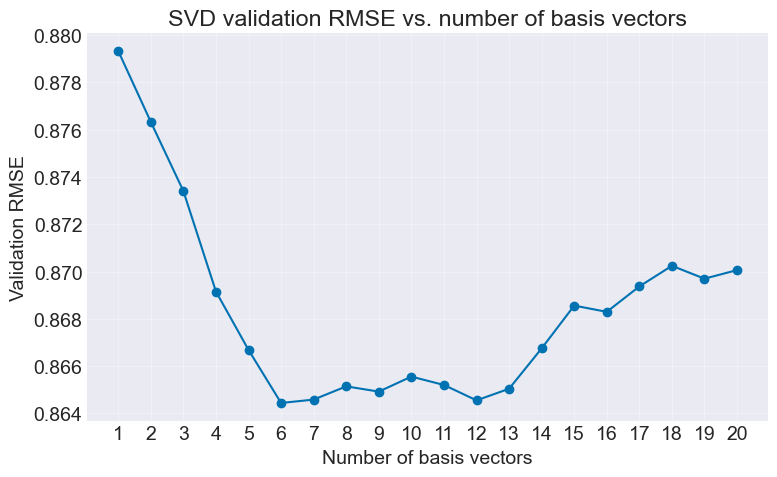

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(svd_basis_counts, svd_val_rmses, marker='o')
plt.xlabel('Number of basis vectors')
plt.ylabel('Validation RMSE')
plt.title('SVD validation RMSE vs. number of basis vectors')
plt.xticks(svd_basis_counts)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2c. Questions

**Question 1:** Based on your analysis, how many basis vectors should you select to get the best generalization accuracy?

**Answer 1:** 6 basis vectors since they gave the lowest validation RMSE in the sweep

## Task 3: Recommender Model 2 (Mean user rating)

In this task the focus is on the **mean user rating model**, which serves as a simple baseline to compare the SVD-based methods with. According to the mean user rating, we predict a user's rating for a movie as:
- the user's movie rating "as-is" if the user already rated that movie.
  - *For example, if user 5 has rated Titanic a 4.5, then the model return 4.5 if predicting user 5's rating for Titanic.*
- the mean of ratings that the user has provided if the user has not rated the queried movie.
  - *For example, if user 2 has not rated Titanic but they have rated 9 movies and across those 9 movies the average rating is 3.2. Then the model returns 3.2.*

In [15]:
from rec_sys import Mean


### 3a. Implement `Mean` recommender classes

In `rec_sys.py` implement and test the following methods in the `Mean` class that inherits from `Recommender`.
- `fit`
- `predict`

#### Test: `fit` and `predict`

In [16]:
test_rec = Mean()
test_A = np.array([[1, 3, 0, 7, 9], [0, 0, 1, 0, 9], [2, 2, 2, 0, 2], [2, 0, 3, 3, 2]], dtype=float)
test_rec.fit(test_A)
print('Your predicted user-item matrix is')
print(test_rec.predict())
print('and should be:')
print('''[[1.  3.  5.  7.  9. ]
 [5.  5.  1.  5.  9. ]
 [2.  2.  2.  2.  2. ]
 [2.  2.5 3.  3.  2. ]]''')
print('The original test matrix is')
print(test_A)
print('and should be:')
print('''[[1. 3. 0. 7. 9.]
 [0. 0. 1. 0. 9.]
 [2. 2. 2. 0. 2.]
 [2. 0. 3. 3. 2.]]''')


Your predicted user-item matrix is
[[1.  3.  5.  7.  9. ]
 [5.  5.  1.  5.  9. ]
 [2.  2.  2.  2.  2. ]
 [2.  2.5 3.  3.  2. ]]
and should be:
[[1.  3.  5.  7.  9. ]
 [5.  5.  1.  5.  9. ]
 [2.  2.  2.  2.  2. ]
 [2.  2.5 3.  3.  2. ]]
The original test matrix is
[[1. 3. 0. 7. 9.]
 [0. 0. 1. 0. 9.]
 [2. 2. 2. 0. 2.]
 [2. 0. 3. 3. 2.]]
and should be:
[[1. 3. 0. 7. 9.]
 [0. 0. 1. 0. 9.]
 [2. 2. 2. 0. 2.]
 [2. 0. 3. 3. 2.]]


### 3b. Evaluate the predicted ratings produced by the mean user rating model

In the cell below:
1. Fit the Mean user rating model to fit set.
2. Print out the **validation set RMSE** in the cell below.

**NOTE:** `predict_user_item_ratings` and `rmse` do NOT take in user-item matrices (i.e. "A" matrices). They take in 1D ndarrays.
- `predict_user_item_ratings`: 1D ndarrays of validation user and movie IDs (i.e. `rows` and `cols` of the validation set ratings, respectively).
- `rmse`: 1D ndarrays of ratings.

In [17]:
mean_rec = Mean()
mean_rec.fit(A_fit)
mean_val_pred = mean_rec.predict_user_item_ratings(rows, cols)
mean_val_rmse = mean_rec.rmse(val_ratings, mean_val_pred)
print(f'Mean user rating validation RMSE: {mean_val_rmse:.5f}')

Mean user rating validation RMSE: 0.91792


## Task 4: Recommender Model 3 (Funk SVD)

Funk SVD, based on SVD and introduced by Simon Funk, reached 3rd place (but did not finish 3rd) on the [Netflix](https://en.wikipedia.org/wiki/Netflix_Prize) [prize](https://sifter.org/~simon/journal/20061211.html).

### 4a. Implement Funk SVD

In `rec_sys.py` implement and test the following methods in the `FunkSVD`:
- constructor
- `get_user_factor_matrix`
- `get_factor_item_matrix`
- `fit`
- `predict`

#### Funk SVD matrix decomposition

With the Funk SVD algorithm, we are attempting to write the user-item matrix $A$ as the product of two other matrices:

$$A \approx UI$$

where $U$ is called the **user-factor** matrix (`shape=(N, K)`), $I$ is called the **factor-item** matrix (`shape=(K, M)`), and $K$ denotes the number of basis vectors (or **factors**) that we are using. That is, we are trying to express the matrix $A$ as the product of two other matrices with appropriate shapes.

#### Funk SVD update equations

In Funk SVD, we initialize $U$ and $I$ with random values and progressively determining better values for each entry based on the error in approximating the original matrix $A$ through an optimization approach called **gradient descent**. The idea is that we initially do a poor job at approximating $A$ and make small tweaks to $U$ and $I$ over many iterations until we ultimately do a good job. 

Unlike regular SVD, Funk SVD makes tweaks to single entries in $U$ and $I$ based on where in $A$ we have actual ratings (i.e. non-zero values). For every actual **non-zero** rating in $A$ at index `i` and `j`, we make an update to both **a row of** $U$ and **a col of** $I$ so that the dot product of this row and col will multiply out to more closely equal the entry in $A$ at index `(i, j)`.

Here are the equations that summarize the change ($dU$ and $dI$) to single entries in $U$ and $I$, respectively, on every iteration of Funk SVD:

$$
dU_{ik} =  -(e I_{kj} - \alpha U_{ik})
$$
$$
dI_{kj} = -(e U_{ik} - \alpha I_{kj})
$$

where $e$ is a float representing the difference between the actual non-zero rating in $A$ at index `(i, j)` and the dot product between row `i` of $U$ and col `j` of $I$. The parameter $\alpha$ is the regularization strength. Then the actual entry in $U$ and $I$ get updated via the update step equation of form $$Blah = Blah - \eta* dBlah$$ where $\eta$ is the step size.

In [18]:
from rec_sys import FunkSVD

#### Test one iteration of `fit` and `predict`

In [19]:
test_rec = FunkSVD(3)
test_A = np.array([[1, 3, 0, 7, 9], [0, 0, 1, 0, 9], [2, 2, 2, 0, 2], [2, 0, 3, 3, 2]], dtype=float)
np.random.seed(0)
test_rec.fit(test_A, step=0.1, n_iter=1, reg=0.5)
print('After 1 iteration of Funk SVD fit, your U matrix looks like')
print(test_rec.get_user_factor_matrix())
print('and it should look like:')
print('''[[0.63286 1.84249 1.05813]
 [0.88374 1.72323 1.26302]
 [0.28009 0.59272 0.64859]
 [0.34602 0.8294  0.49223]]''')
print('\nAfter 1 iteration of Funk SVD fit, your I matrix looks like')
print(test_rec.get_factor_item_matrix())
print('and it should look like:')
print('''[[0.54052 0.91272 0.21688 0.46429 0.704  ]
 [0.83058 0.80366 1.02611 1.38696 1.59438]
 [0.49471 0.79101 0.3385  0.99201 1.0269 ]]''')


After 1 iteration of Funk SVD fit, your U matrix looks like
None
and it should look like:
[[0.63286 1.84249 1.05813]
 [0.88374 1.72323 1.26302]
 [0.28009 0.59272 0.64859]
 [0.34602 0.8294  0.49223]]

After 1 iteration of Funk SVD fit, your I matrix looks like
None
and it should look like:
[[0.54052 0.91272 0.21688 0.46429 0.704  ]
 [0.83058 0.80366 1.02611 1.38696 1.59438]
 [0.49471 0.79101 0.3385  0.99201 1.0269 ]]


In [20]:
print('After 1 iteration of Funk SVD fit, your predicted A matrix is')
print(test_rec.predict())
print('and it should be')
print('''[[2.39587 2.89535 2.38603 3.89896 4.46976]
 [2.53379 3.19057 2.38743 4.05328 4.66663]
 [0.96456 1.24503 0.88849 1.59552 1.80824]
 [1.11942 1.37173 1.09272 1.79928 2.07144]]''')

After 1 iteration of Funk SVD fit, your predicted A matrix is
None
and it should be
[[2.39587 2.89535 2.38603 3.89896 4.46976]
 [2.53379 3.19057 2.38743 4.05328 4.66663]
 [0.96456 1.24503 0.88849 1.59552 1.80824]
 [1.11942 1.37173 1.09272 1.79928 2.07144]]


### 4b. Compare the test accuracy of mean user rating, SVD, and Funk SVD recommender systems

In the cell below fit each of the three recommender system models on the MovieLens fit set and evaluate the RMSE error on the validation set.

When setting up your recommender system fits
- use the optimal number of basis vectors when fitting the SVD model that you determined in your analysis above.
- Use `4` basis vectors for Funk SVD and the defaults for the other parameters.


Create a "high quality" [horizontal side bar chart](https://matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html) that summarizes the accuracy of all three models.
- Make the y values correspond to the 3 models and the x values should the corresponding RMSE value on the test set.
- Either annotate your bars with the numeric RMSE values or print them out.

**NOTE:** It should take a few minutes for Funk SVD to run. Something may be wrong if the runtime exceeds 5 minutes, even on slower computers.

In [21]:
np.random.seed(0)

# YOUR CODE HERE

### 4c. Questions

**Question 2:** Rank the models from best to worst based on the average error they make in their recommendations on the validation set.

**Answer 2:** 

YOUR ANSWER HERE

## Task 5: Recommend movies to users

Now that you have built recommender systems that predict how users will rate a movie, let's do what streaming services do — recommend which movies a specific user will like most that they have not seen!

The next several subtasks focus on leveraging some provided functions in `rec_util.py` to help analyze the movie recommendations.

In [22]:
import rec_util

Execute the following cell to load in a Python dictionary that maps the movieId int to the movie's string name. We will need this to recommend human-interpretable movie names to users, as opposed to their int ID.

In [23]:
# Keep this code, which loads in the MovieLens movieId-to-movie-title map
# as a dictionary
fp = open('data/movielens/movie_map.pkl', 'rb')
movie_map = pickle.load(fp)
fp.close()

FileNotFoundError: [Errno 2] No such file or directory: 'data/movielens/movie_map.pkl'

### 5a. Streaming app first launch experience

Imagine you are a developer for a popular streaming app and you are designing the experience a user will encounter they first open the app. You have no data on the user, but you would like to present 10 movies they are likely to want to watch to encourage them to continue using your app. While do not have any ratings from the new user to help us provide them with recommendations, we do have ratings and predictions for all existing users. The strategy we will take is to recommend the new user movies that your recommendation system predicts existing users are most likely to enjoy.

In the cell below:
1. Use your fitted best performing recommendation system and obtain the user-item matrix of predicted ratings for all existing users.
2. Average the predicted ratings across all users for all existing movies.
3. Populate and print an array of the movie title strings that have the `top_k` highest average predicted ratings.

Make sure the rank ordering of the movie recommendations is clear from the print outs.

*Hint: Once you have the average predicted ratings, determining the top movie strings is very similar to what you did in lab once you computed the predicted recipe ratings. Replace the unrated movieIDs with an array going from 0 to num_movies-1.*

In [ ]:
# YOUR CODE HERE

### 5b. Questions

**Question 3:** Sanity check: does the list of top 10 movies to recommend the new user appear reasonable? Why or why not?

**Answer 3:**

YOUR ANSWER HERE

### 5c. Determine a user's top rated movies

The goal of this subtask is to glean the known movie tastes of a selected user.

In the cell below, use the provided `get_top_rated_movies` function in `rec_util` to print out below the top 10 rated movies rated by MovieLens user with userId `1` based on the fit set.

*Make sure the rank ordering of the movies is clear from the print outs.*

In [ ]:
# YOUR CODE HERE

### 5d. Determine top recommendations of movies a user has not seen

1. Copy-and-paste your code from lab's Task L3 into the `get_top_recommendations` function in `rec_util.py` (starting with step 1). Adjust your variable naming as necessary to suit the function parameters for the following items:
- User-item matrix `A`
- current user ID `user_id`
- Number of top recommendations to retrieve `num_top_recommendations`
- Movie ID to string name map `movie_map`

2. Remove the code from step 4 of lab Task L3 that generates the 1D array of predicted ratings. Replace it with a single line of code that calls the `predict_user_item_ratings` method of the `rec_model` object passed into the function.
3. Add a line of code toward the bottom of the function that determines the predicted numerical RATINGS of the top-k recommended movies. *This should make use of variables you already have: the predicted ratings and the INDICES of the top unrated movies.* 
4. Have the function return both the top recommended movie titles and associated predicted ratings.
5. Test your code out by running the cell below that uses your SVD recommender model.
6. Comment out all debugging print outs in the function to reduce clutter.

#### Test `get_top_recommendations`

In [ ]:
from rec_sys import SVD

In [ ]:
np.random.seed(0)
test_A = np.array([[0, 1, 2, 3, 4, 4.5, 5],
                   [0, 0, 0, 5, 0, 1, 4],
                   [3, 2, 0, 5, 0, 0, 0]])
test_movie_map = {0: 'The Shawshank Redemption',
                  1: 'The Godfather',
                  2: 'Pulp Fiction',
                  3: 'The Dark Knight',
                  4: 'Titanic',
                  5: 'Inception',
                  6: 'Jurassic Park'}
test_rec = SVD(1)
test_rec.fit(test_A)
test_titles, test_pred_ratings = rec_util.get_top_recommendations(test_A, test_rec, test_movie_map, user_id=1, num_top_recommendations=3)
print(f'User {1}s movie ratings are:')
print(test_A[1])
print(f'User {1}s top 3 recommended movies that have not been rated:')
print(test_titles)
print('and should be:')
print(['Pulp Fiction', 'Titanic', 'The Shawshank Redemption'])
print(f'There predicted ratings are:')
print(test_pred_ratings)
print('and should be:')
print('[3.54641 3.22679 3.21726]')
print()

test_titles, test_pred_ratings = rec_util.get_top_recommendations(test_A, test_rec, test_movie_map, user_id=2, num_top_recommendations=3)
print(f'User {2}s movie ratings are:')
print(test_A[2])
print(f'User {2}s top 3 recommended movies that have not been rated:')
print(test_titles)
print('and should be:')
print(['Jurassic Park', 'Titanic', 'Pulp Fiction'])
print(f'There predicted ratings are:')
print(test_pred_ratings)
print('and should be:')
print('[4.04485 3.51443 2.97114]')
print()

### 5e. Explore user movie recommendations

Use your best performing model from Task 5b to generate top-10 movie recommendations for 3 users. For each user, you should
1. Print the titles of the top 10 movies rated by user `i`.
2. Use the provided `plot_recommendations` function in `rec_util` to visualize the top 10 recommended movies unrated by user `i` along with their predicted ratings.
3. Based on your familiarity with the movies, evaluate the extent to which the recommendations make sense to you in light of the user's top rated movies. *If you are not familiar with the set of movies associated with a particular user, look them up or pick a different user!*

**One of the users that you pick should be User 1 (has `userId` of `1`)**.

**Note:** The model should only be fit on the fit set!

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE